In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from integral_functions.weight_functions import get_weights, get_interval_grid_points, get_interval_population_density
from integral_functions.methods.inducing_points import get_discretizations, midpoint_to_disc
from numpy.typing import NDArray
from scipy.special import expit
from scipy.integrate import quad
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from regmod.models.binomial import BinomialModel
from regmod.parameter import Parameter
from regmod.variable import Variable
# from msca.integrate.integration_weights import build_integration_weights

# For more Cython info on the import statement, visit the link: https://stackoverflow.com/questions/7508803/how-do-i-import-function-from-pyx-file-in-python

from integral_functions.methods.inducing_points import get_discretizations
from integral_functions.simulation.age_distribution import age_distribution
from integral_functions.simulation.death_rate import death_rate_function, expit_death_rate_function, func1, func2, func3
from integral_functions.simulation.sampling import sample_probability_of_death
from integral_functions.simulation.age_intervals import bounded_intervals_generator, int_bounded_intervals_generator, pop_density_generator
from integral_functions.simulation.integrate_functions import integrate_cov, integrate_denom

#### Uniform 1-year age groups

In [3]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

grid_points = np.arange(start=(low_age + 0.5), stop=(high_age + 0.5), step=1)
discretizations = get_discretizations(0,95, grid_points=grid_points)
population_list = []
for i in range(1,len(discretizations)):
    integral_over_interval = integrate_denom(age_distribution, discretizations[i-1], discretizations[i], age_mid=age_mid)
    population_list.append(integral_over_interval)
population_densities = np.array(population_list)
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have. I think this is something we can control.

In [65]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 10
age_interval_ub = 15
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df["obs"] = df.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args = {"c1": c1}
    ),
    axis=1,
)

# add grid_points: here I'm doing this on integers (and hence use arange). We can change
# this to np.linspace() for when we are not using integers. I'm just using integers because
# it felt like it would make more sense to me.
df["grid_points_with_indices"] = df.apply(
    lambda row: np.intersect1d(
        ar1=grid_points[grid_points >= row.iloc[0]],
        ar2=grid_points[grid_points <= row.iloc[1]],
        return_indices=True
    ),
    axis=1
)

df[["grid_points", "indices_left", "indices_right"]] = df["grid_points_with_indices"].apply(pd.Series)

df = df.drop(columns=["grid_points_with_indices"])

# Get population densities
df["pop_density"] = df.apply(
    lambda row: population_densities[row.loc["indices_right"]],
    axis=1
)

# Get weights
df["weights"] = df.apply(
    lambda row: get_weights(
        lb=row.iloc[0],
        ub=row.iloc[1],
        population_density=row.iloc[-1],
        grid_points=row.iloc[4],
    ),
    axis=1
)

# # Get function evaluations
df["function_evals1"] = df["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df["function_evals2"] = df["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df["function_evals3"] = df["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df["cov1"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals1),
    axis=1
)
df["cov2"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals2),
    axis=1
)
df["cov3"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals3),
    axis=1
)
df["denom"] = df.apply(
    lambda row: np.sum(row.pop_density),
    axis=1
)

df["cov1"] /= df["denom"]
df["cov2"] /= df["denom"]
df["cov3"] /= df["denom"]

# Get constructed outcomes
df["outcomes"] = expit((c1 * df["cov1"] + c2 * df["cov2"] + c3 * df["cov3"]))

# df = df.loc[:, [x for x in df.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

In [66]:
df.head()

,age_start,age_end,sample_size,obs,grid_points,indices_left,indices_right,pop_density,weights,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,denom,outcomes
0,44,54,77,0.051948,"[44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[44, 45, 46, 47, 48, 49, 50, 51, 52, 53]","[28.80327039814816, 28.092137064814825, 27.389...","[28.80327039814816, 28.092137064814825, 27.389...","[44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51....","[-6.670832032063167, -6.745368781616021, -6.81...","[1980.25, 2070.25, 2162.25, 2256.25, 2352.25, ...",48.783215,-6.981488,2388.014161,257.098371,0.053500
1,47,59,69,0.101449,"[47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]","[26.696537064814823, 26.012070398148154, 25.33...","[26.696537064814823, 26.012070398148154, 25.33...","[47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54....","[-6.892024376045111, -6.96419413859206, -7.035...","[2256.25, 2352.25, 2450.25, 2550.25, 2652.25, ...",52.669757,-7.253531,2785.932352,277.139200,0.078365
2,64,78,46,0.565217,"[64.5, 65.5, 66.5, 67.5, 68.5, 69.5, 70.5, 71....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 7...","[16.26949262037038, 15.736137064814823, 15.211...","[16.26949262037038, 15.736137064814823, 15.211...","[64.5, 65.5, 66.5, 67.5, 68.5, 69.5, 70.5, 71....","[-8.031189202104505, -8.093207028119323, -8.15...","[4160.25, 4290.25, 4422.25, 4556.25, 4692.25, ...",70.401528,-8.387195,4972.337890,182.473097,0.533993
3,67,79,54,0.648148,"[67.5, 68.5, 69.5, 70.5, 71.5, 72.5, 73.5, 74....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78]","[14.696092620370376, 14.189403731481487, 13.69...","[14.696092620370376, 14.189403731481487, 13.69...","[67.5, 68.5, 69.5, 70.5, 71.5, 72.5, 73.5, 74....","[-8.215838362577491, -8.276472678623424, -8.33...","[4556.25, 4692.25, 4830.25, 4970.25, 5112.25, ...",72.543713,-8.514889,5274.339777,144.867200,0.628090
4,67,81,95,0.684211,"[67.5, 68.5, 69.5, 70.5, 71.5, 72.5, 73.5, 74....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 7...","[14.696092620370376, 14.189403731481487, 13.69...","[14.696092620370376, 14.189403731481487, 13.69...","[67.5, 68.5, 69.5, 70.5, 71.5, 72.5, 73.5, 74....","[-8.215838362577491, -8.276472678623424, -8.33...","[4556.25, 4692.25, 4830.25, 4970.25, 5112.25, ...",73.366753,-8.562282,5398.608834,162.872163,0.665682


In [67]:
model_discrete_1 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

In [68]:
model_discrete_1.fit()

In [69]:
model_discrete_1.opt_result.x

array([0.00414232, 0.99397788, 0.00162963])

In [70]:
df_pred = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred["cov1"] = func1(df_pred["age_mid"])
df_pred["cov2"] = func2(df_pred["age_mid"])
df_pred["cov3"] = func3(df_pred["age_mid"])
df_pred = model_discrete_1.predict(df_pred)
df_pred["p_true"] = expit_death_rate_function(df_pred["age_mid"], c1=c1)

In [71]:
df_pred

,age_mid,cov1,cov2,cov3,p,p_true
0,0.00,0.00,-0.000000,0.0000,0.500000,0.500000
1,0.95,0.95,-0.974679,0.9025,0.276197,0.274443
2,1.90,1.90,-1.378405,3.6100,0.204834,0.202560
3,2.85,2.85,-1.688194,8.1225,0.160706,0.158219
4,3.80,3.80,-1.949359,14.4400,0.130296,0.127749
...,...,...,...,...,...,...
96,91.20,91.20,-9.549869,8317.4400,0.988339,0.990815
97,92.15,92.15,-9.599479,8491.6225,0.990791,0.992814
98,93.10,93.10,-9.648834,8667.6100,0.992753,0.994399
99,94.05,94.05,-9.697938,8845.4025,0.994318,0.995650


Text(0.5, 1.0, 'Discrete weights uniform spacing = 1')

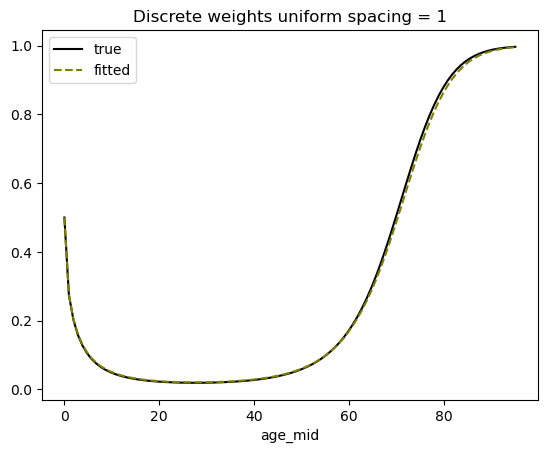

In [72]:
fig, ax = plt.subplots()
ax.plot(df_pred["age_mid"], df_pred["p_true"], color="k", label="true")
ax.plot(df_pred["age_mid"], df_pred["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
# ax.set_yscale("log")
plt.title("Discrete weights uniform spacing = 1")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

#### Uniform 5-year age groups

In [2]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

step = 5

# Make sure to go above high_age by just a little bit on the grid_point construction
grid_points = np.arange(start=(low_age + 2.5), stop=(high_age + step + 0.5), step=step)
discretizations = get_discretizations(low_age,high_age, grid_points=grid_points)
population_list = []
for i in range(1,len(discretizations)):
    integral_over_interval = integrate_denom(age_distribution, discretizations[i-1], discretizations[i], age_mid=age_mid)
    population_list.append(integral_over_interval)
population_densities = np.array(population_list)
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have.

In [3]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df5 = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df5["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df5["obs"] = df5.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args = {"c1": c1}
    ),
    axis=1,
)

# add grid_points.
df5["grid_points"] = df5.apply(
    lambda row: get_interval_grid_points(
        lb=row.loc["age_start"],
        ub=row.loc["age_end"],
        grid_points=grid_points
    ),
    axis=1)

df5["pop_density"] = df5.apply(
    lambda row: get_interval_population_density(
        lb=row.loc["age_start"],
        ub=row.loc["age_end"],
        population_density=population_densities,
        grid_points=grid_points
    ),
    axis=1)

# Get weights
df5["weights"] = df5.apply(
    lambda row: get_weights(
        lb=row.iloc[0],
        ub=row.iloc[1],
        population_density=population_densities,
        grid_points=grid_points,
    ),
    axis=1
)

# Get function evaluations
df5["function_evals1"] = df5["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df5["function_evals2"] = df5["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df5["function_evals3"] = df5["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df5["cov1"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals1),
    axis=1
)
df5["cov2"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals2),
    axis=1
)
df5["cov3"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals3),
    axis=1
)
df5["denom"] = df5.apply(
    lambda row: np.sum(row.pop_density),
    axis=1
)

df5["cov1"] /= df5["denom"]
df5["cov2"] /= df5["denom"]
df5["cov3"] /= df5["denom"]

# Get constructed outcomes
df5["outcomes"] = expit((c1 * df5["cov1"] + c2 * df5["cov2"] + c3 * df5["cov3"]))

# df5 = df5.loc[:, [x for x in df5.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

This is the age bin length: [3.5 5.  5.  5.  4.5]
This is the age bin length: [0.5 5.  5.  5.  4.5]
This is the age bin length: [3.5 5.  5.  5.  5.  4.5]
This is the age bin length: [3.5 5.  5.  5.  5.  4.5]
This is the age bin length: [1.5 5.  5.  5.  4.5]
This is the age bin length: [1.5 5.  5.  5.  5.  5.  1.5]
This is the age bin length: [0.5 5.  5.  5.  5.  5.  1.5]
This is the age bin length: [4.5 5.  5.  5.  5.  0.5]
This is the age bin length: [3.5 5.  5.  5.  5.  3.5]
This is the age bin length: [1.5 5.  5.  5.  5.  5.  2.5]
This is the age bin length: [0.5 5.  5.  5.  5.  3.5]
This is the age bin length: [2.5 5.  5.  5.  2.5]
This is the age bin length: [3.5 5.  5.  5.  5.  3.5]
This is the age bin length: [2.5 5.  5.  5.  4.5]
This is the age bin length: [0.5 5.  5.  5.  5.  2.5]
This is the age bin length: [3.5 5.  5.  5.  5.  5.  0.5]
This is the age bin length: [3.5 5.  5.  5.  5.  1.5]
This is the age bin length: [3.5 5.  5.  5.  5.  0.5]
This is the age bin length: [3.5

To take care of hanging edges like we see below, reference the integration_weights.py function that Peng sent.

In [18]:
disc_arr1 = np.insert(df5["grid_points"][0], 1, df5["age_start"][0])
poplist = []
for i in range(1,len(disc_arr1)):
    integral_over_interval = integrate_denom(age_distribution, disc_arr1[i-1], disc_arr1[i], age_mid=age_mid)
    poplist.append(integral_over_interval)
pop_dens = np.array(poplist)

In [19]:
pop_dens

array([ 44.55772504,  97.7196825 , 125.05462977, 108.9429631 ,
        93.94240755])

In [20]:
np.dot(df5["grid_points"][0], pop_dens) / np.sum(pop_dens)

53.669593508702526

In [11]:
df5["pop_density"][0]

array([133.52712977, 116.85990755, 101.30379644,  86.85879644,
        73.52490755])

Use this second one

In [37]:
disc_arr1 = get_interval_grid_points(lb=44, ub=67, grid_points=np.arange(start=0, stop=95, step=5))
disc_arr1[0] = 44
poplist = []
for i in range(1,len(disc_arr1)):
    integral_over_interval = integrate_denom(age_distribution, disc_arr1[i-1], disc_arr1[i], age_mid=age_mid)
    poplist.append(integral_over_interval)
pop_dens = np.array(poplist)
pop_dens

array([ 28.8032704 , 133.52712977, 116.85990755, 101.30379644,
        86.85879644])

In [38]:
disc_arr1

array([44, 45, 50, 55, 60, 65])

In [39]:
np.dot(df5["grid_points"][0], pop_dens) / np.sum(pop_dens)

53.39747724509717

In [6]:
df5.head()

,age_start,age_end,sample_size,obs,grid_points,pop_density,weights,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,"[42.5, 47.5, 52.5, 57.5, 62.5]","[151.3054631018519, 133.52712976851856, 116.85...","[529.5691208564816, 667.6356488425928, 584.299...","[42.5, 47.5, 52.5, 57.5, 62.5]","[-6.519202405202649, -6.892024376045111, -7.24...","[1806.25, 2256.25, 2756.25, 3306.25, 3906.25]",197.903327,-27.924811,10032.442369,589.855093,2.319026e-05
1,47,67,54,0.092593,"[42.5, 47.5, 52.5, 57.5, 62.5]","[151.3054631018519, 133.52712976851856, 116.85...","[75.65273155092595, 667.6356488425928, 584.299...","[42.5, 47.5, 52.5, 57.5, 62.5]","[-6.519202405202649, -6.892024376045111, -7.24...","[1806.25, 2256.25, 2756.25, 3306.25, 3906.25]",165.197928,-22.908031,8642.462885,589.855093,3.187941e-04
2,64,92,94,0.670213,"[62.5, 67.5, 72.5, 77.5, 82.5, 87.5]","[86.85879643518521, 73.52490754629632, 61.3021...","[304.00578752314823, 367.6245377314816, 306.51...","[62.5, 67.5, 72.5, 77.5, 82.5, 87.5]","[-7.905694150420948, -8.215838362577491, -8.51...","[3906.25, 4556.25, 5256.25, 6006.25, 6806.25, ...",301.233598,-35.572497,21750.584532,343.366668,8.461515e-01
3,9,37,62,0.016129,"[7.5, 12.5, 17.5, 22.5, 27.5, 32.5]","[138.33333333333331, 168.33333333333337, 188.3...","[484.16666666666663, 841.6666666666669, 941.66...","[7.5, 12.5, 17.5, 22.5, 27.5, 32.5]","[-2.7386127875258306, -3.5355339059327378, -4....","[56.25, 156.25, 306.25, 506.25, 756.25, 1056.25]",77.106481,-17.298171,1665.345293,1080.000000,5.630045e-07
4,21,42,35,0.000000,"[17.5, 22.5, 27.5, 32.5, 37.5]","[188.33333333333337, 198.33333333333331, 198.3...","[282.50000000000006, 991.6666666666665, 991.66...","[17.5, 22.5, 27.5, 32.5, 37.5]","[-4.183300132670378, -4.743416490252569, -5.24...","[306.25, 506.25, 756.25, 1056.25, 1406.25]",93.608650,-17.991463,2599.602637,943.528241,1.400710e-06


Need to separate data-generating process from the estimation/inference process. So come up with a function that only creates the columns "age_start", "age_end", "sample_size", and "obs", since these values just come from the data. The process like Kreg or SPXMod will implicitly create the rest of the columns to then fit a model like we do below.

In [232]:
model_discrete_5 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df5,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

model_discrete_5.fit()

model_discrete_5.opt_result.x

array([9.09567653e-02, 1.32803228e+00, 9.60558409e-04])

In [233]:
df_pred5 = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred5["cov1"] = func1(df_pred5["age_mid"])
df_pred5["cov2"] = func2(df_pred5["age_mid"])
df_pred5["cov3"] = func3(df_pred5["age_mid"])
df_pred5 = model_discrete_5.predict(df_pred5)
df_pred5["p_true"] = expit_death_rate_function(df_pred5["age_mid"], c1=c1)

#### Continuous setting

In [42]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df_analytic = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df_analytic["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df_analytic["obs"] = df_analytic.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args= {"c1": c1}
    ),
    axis=1,
)

# add covariates
func_list = [func1, func2, func3]
for i, func in enumerate(func_list):
    df_analytic["cov" + str(i + 1)] = df_analytic.apply(
        lambda row: integrate_cov(
            func=func,
            density=age_distribution,
            age_start=row.iloc[0],
            age_end=row.iloc[1],
            age_mid=age_mid
        ),
        axis=1,
    )

# add denominators
df_analytic["denom"] = df_analytic.apply(
    lambda row: integrate_denom(
        density=age_distribution,
        age_start=row.iloc[0],
        age_end=row.iloc[1],
        age_mid=age_mid
    ),
    axis=1,
)

# Add outcomes -- the y_i's
df_analytic["cov1"] = df_analytic["cov1"] / df_analytic["denom"]
df_analytic["cov2"] = df_analytic["cov2"] / df_analytic["denom"]
df_analytic["cov3"] = df_analytic["cov3"] / df_analytic["denom"]
df_analytic["outcomes"] = expit((c1 * df_analytic["cov1"] + c2 * df_analytic["cov2"] + c3 * df_analytic["cov3"]))

In [43]:
df_analytic

,age_start,age_end,sample_size,obs,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,54.242932,-7.351654,2985.117748,498.300708,0.097730
1,47,67,54,0.092593,56.026660,-7.475428,3171.563412,414.015408,0.116321
2,64,92,94,0.670213,75.299857,-8.666320,5729.612287,283.057393,0.759387
3,9,37,62,0.016129,23.282353,-4.750777,603.666576,1042.469141,0.024097
4,21,42,35,0.000000,31.041881,-5.545434,999.245084,778.734937,0.021548
...,...,...,...,...,...,...,...,...,...
995,50,78,95,0.210526,61.894968,-7.851637,3892.791080,471.226104,0.236494
996,53,79,88,0.352273,64.120884,-7.994647,4165.007628,408.792608,0.299430
997,10,33,39,0.025641,21.827005,-4.616541,518.747051,868.173333,0.023826
998,43,65,11,0.090909,52.872907,-7.258651,2834.863397,496.876193,0.084207


In [44]:
model_cont = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df_analytic,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

model_cont.fit()

model_cont.opt_result.x

array([8.22648507e-02, 1.29620903e+00, 1.03733268e-03])

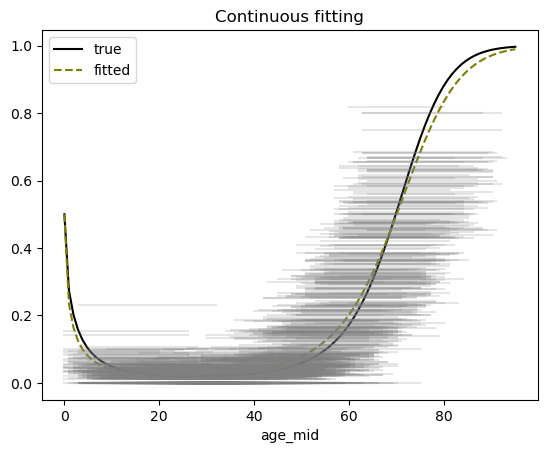

In [45]:
df_pred_cont = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred_cont["cov1"] = func1(df_pred_cont["age_mid"])
df_pred_cont["cov2"] = func2(df_pred_cont["age_mid"])
df_pred_cont["cov3"] = func3(df_pred_cont["age_mid"])
df_pred_cont = model_cont.predict(df_pred_cont)
df_pred_cont["p_true"] = expit_death_rate_function(df_pred_cont["age_mid"], c1=c1)

fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous fitting")

for _, row in df.iterrows():
    ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

Text(0.5, 1.0, 'Continuous v discrete fitting')

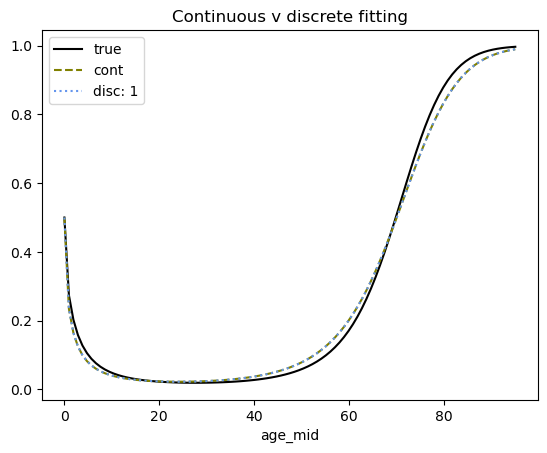

In [46]:
fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="cont")
ax.plot(df_pred["age_mid"], df_pred["p"], color="cornflowerblue", linestyle="dotted", label="disc: 1")
# ax.plot(df_pred["age_mid"], df_pred5["p"], color="salmon", linestyle="dashdot", label="disc: 5")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting")
# plt.yscale("log")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

Text(0.5, 1.0, 'Continuous v discrete fitting - logit')

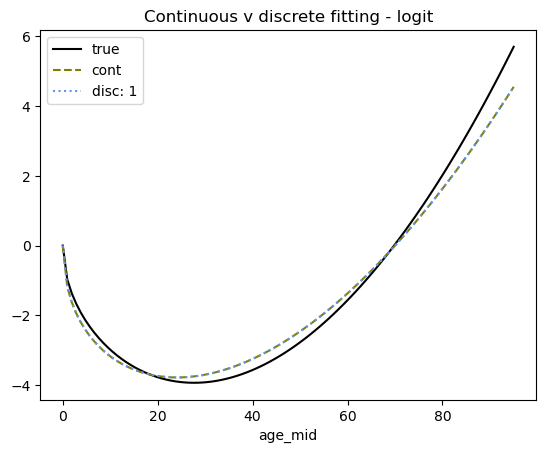

In [47]:
from scipy.special import logit
fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], logit(df_pred_cont["p_true"]), color="k", label="true")
ax.plot(df_pred_cont["age_mid"], logit(df_pred_cont["p"]), color="olive", linestyle="--", label="cont")
ax.plot(df_pred["age_mid"], logit(df_pred["p"]), color="cornflowerblue", linestyle="dotted", label="disc: 1")
# ax.plot(df_pred["age_mid"], logit(df_pred5["p"]), color="salmon", linestyle="dashdot", label="disc: 5")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting - logit")

In [235]:
print(f"This is the MSE for discrete-uniform fitting with 1 spacing: {mean_squared_error(df_pred["p"], df_pred["p_true"])}")
print(f"This is the MSE for discrete-uniform fitting with 5 spacing: {mean_squared_error(df_pred5["p"], df_pred["p_true"])}")
print(f"This is the MSE for continuous fitting: {mean_squared_error(df_pred_cont["p"], df_pred["p_true"])}")

This is the MSE for discrete-uniform fitting with 1 spacing: 0.000486706731798817
This is the MSE for discrete-uniform fitting with 5 spacing: 0.0006737907245730978
This is the MSE for continuous fitting: 0.00048637993449083454


In [236]:
print(f"This is the MAE for discrete-uniform fitting with 1 spacing: {mean_absolute_error(df_pred["p"], df_pred["p_true"])}")
print(f"This is the MAE for discrete-uniform fitting with 5 spacing: {mean_absolute_error(df_pred5["p"], df_pred["p_true"])}")
print(f"This is the MAE for continuous fitting: {mean_absolute_error(df_pred_cont["p"], df_pred["p_true"])}")

This is the MAE for discrete-uniform fitting with 1 spacing: 0.017449422557233946
This is the MAE for discrete-uniform fitting with 5 spacing: 0.020048670514198386
This is the MAE for continuous fitting: 0.017447987808207804
